In [63]:
print("Live Bitcoin Tracker")
print("ETL Pipeline")
print("Project started successfully!")

Live Bitcoin Tracker
ETL Pipeline
Project started successfully!


In [1]:
import requests
import pandas as pd
import datetime
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
print("Libraries imported successfully")

Libraries imported successfully


### ETL Pipeline

Extract (API Data)

Transform (Pandas and Python)

Load data

Analyse


In [ ]:
url = "https://api.coingecko.com/api/v3/ping"
response = requests.get(url, timeout=10)

print("Status code:", response.status_code)
print("Response:", response.text)

In [ ]:
crypto_url = "https://api.coingecko.com/api/v3/simple/price"

params = {
    "ids": "bitcoin",
    "vs_currencies": "aud"
}

response = requests.get(
    crypto_url,
    params = params,
    timeout = 10
)

print("Status code:", response.status_code)
print(response.json())

In [12]:
data = response.json()
btc_price_aud = data['bitcoin']["aud"]

print("Bitcoin price:", btc_price_aud)

Bitcoin price: 118081


In [63]:
print("AAPL USD:", aapl_price_usd)
print("USD → AUD:", usd_to_aud)
print("AAPL AUD:", aapl_price_aud)
print("BTC AUD:", btc_price_aud)

AAPL USD: 338.4
USD → AUD: 1.424
AAPL AUD: 481.88159999999993
BTC AUD: 118471.0


## Create API Configuration

In [3]:
pip install python-dotenv


Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [7]:
ALPHA_VANTAGE_API_KEY = os.getenv(
    "ALPHA_VANTAGE_API_KEY"
)
print("API key configured:", bool(ALPHA_VANTAGE_API_KEY))

API key configured: True


## Extract AAPL 


In [13]:
stock_url = "https://www.alphavantage.co/query"

stock_params = {
    "function": "TIME_SERIES_DAILY",
    "symbol": "AAPL",
    "outputsize": "compact",
    "apikey": ALPHA_VANTAGE_API_KEY
}

stock_response = requests.get(
    stock_url,
    params=stock_params,
    timeout=10
)

print("Status code:", stock_response.status_code)

stock_data = stock_response.json()
print(stock_data.keys())

Status code: 200
dict_keys(['Meta Data', 'Time Series (Daily)'])


In [20]:
### AAPL response


In [14]:
print(stock_data["Time Series (Daily)"])

{'2026-09-28': {'1. open': '340.3700', '2. high': '342.9880', '3. low': '338.0400', '4. close': '338.4000', '5. volume': '32820848'}, '2026-09-25': {'1. open': '336.0400', '2. high': '341.6700', '3. low': '334.5300', '4. close': '341.0700', '5. volume': '30002507'}, '2026-09-24': {'1. open': '336.7200', '2. high': '338.9100', '3. low': '334.3000', '4. close': '335.9200', '5. volume': '24733098'}, '2026-09-23': {'1. open': '341.0750', '2. high': '341.8000', '3. low': '335.5000', '4. close': '337.0200', '5. volume': '31658823'}, '2026-09-22': {'1. open': '340.1350', '2. high': '345.3400', '3. low': '338.7500', '4. close': '339.7500', '5. volume': '40711786'}, '2026-09-21': {'1. open': '335.2800', '2. high': '339.6400', '3. low': '333.0500', '4. close': '338.9800', '5. volume': '34999229'}, '2026-09-18': {'1. open': '337.9050', '2. high': '338.4900', '3. low': '332.5300', '4. close': '336.1300', '5. volume': '86588203'}, '2026-09-17': {'1. open': '334.7700', '2. high': '338.3400', '3. low

In [23]:
## Available AAPL Trading day

In [15]:
time_series = stock_data["Time Series (Daily)"]
latest_date = sorted(time_series.keys())[-1]
latest_aapl_data = time_series[latest_date]

print("Latest trading date:", latest_date)
print("AAPL data:", latest_aapl_data)

Latest trading date: 2026-09-28
AAPL data: {'1. open': '340.3700', '2. high': '342.9880', '3. low': '338.0400', '4. close': '338.4000', '5. volume': '32820848'}


In [16]:
aapl_price_usd = float(latest_aapl_data["4. close"])

print(f"AAPL closing price: ${aapl_price_usd:,.2f} USD")

AAPL closing price: $338.40 USD


### Testing Exchange rate API


In [17]:
fx_url = "https://api.frankfurter.dev/v2/rate/usd/aud"

fx_response = requests.get(
    fx_url,
    timeout = 10
)

print("Status code:", fx_response.status_code)
print(fx_response.json())

Status code: 200
{'date': '2026-09-29', 'base': 'USD', 'quote': 'AUD', 'rate': 1.424}


### Now Extract the USD/AUD rate


In [18]:
fx_data = fx_response.json()
usd_to_aud = float(fx_data["rate"])

print(f"USD -> AUD: {usd_to_aud: .4f}")

USD -> AUD:  1.4240


### Convert AAPL USD to AUD

In [19]:
aapl_price_aud = aapl_price_usd * usd_to_aud

print(f"AAPL price: ${aapl_price_usd:,.2f} USD")
print(f"USD → AUD: {usd_to_aud:.4f}")
print(f"AAPL price: ${aapl_price_aud:,.2f} AUD")

AAPL price: $338.40 USD
USD → AUD: 1.4240
AAPL price: $481.88 AUD


### Extract Bitcoin 

In [22]:
crypto_url ="https://api.coingecko.com/api/v3/simple/price"

crypto_params = {
    "ids": "bitcoin",
    "vs_currencies": "aud"
}

crypto_response = requests.get(
    crypto_url,
    params = crypto_params,
    timeout =10
)

print("Status code:", crypto_response.status_code)

crypto_data = crypto_response.json()

btc_price_aud = float(
    crypto_data["bitcoin"]["aud"]
)

print(f"Bitcoin price: ${btc_price_aud:,.2f} AUD")


Status code: 200
Bitcoin price: $118,479.00 AUD


In [23]:
print("AAPL USD:", aapl_price_aud)
print("USD -> AUD:", usd_to_aud)
print("AAPL AUD:", aapl_price_aud)
print("BTC AUD:", btc_price_aud)

AAPL USD: 481.88159999999993
USD -> AUD: 1.424
AAPL AUD: 481.88159999999993
BTC AUD: 118479.0


### Combine in Json

In [64]:
market_data = {
    "aapl": {
        "price_usd": aapl_price_usd,
        "price_aud": aapl_price_aud,
        "date": latest_date
    },
    "bitcoin": {
        "price_aud": btc_price_aud
    },
    "exchange_rate": {
        "usd_to_aud": usd_to_aud
    }
}

market_data

{'aapl': {'price_usd': 338.4,
  'price_aud': 481.88159999999993,
  'date': '2026-09-28'},
 'bitcoin': {'price_aud': 118471.0},
 'exchange_rate': {'usd_to_aud': 1.424}}

In [25]:
print("========== MARKET DATA ==========")

print(f"AAPL")
print(f"  Trading date : {latest_date}")
print(f"  USD price    : ${aapl_price_usd:,.2f}")
print(f"  AUD price    : ${aapl_price_aud:,.2f}")

print()

print("Bitcoin")
print(f"  AUD price    : ${btc_price_aud:,.2f}")

print()

print("Exchange Rate")
print(f"  USD → AUD     : {usd_to_aud:.4f}")

print("=================================")

========== MARKET DATA ==========
AAPL
  Trading date : 2026-09-28
  USD price    : $338.40
  AUD price    : $481.88

Bitcoin
  AUD price    : $118,479.00

Exchange Rate
  USD → AUD     : 1.4240


### Error Handling

In [27]:
def get_json(url, params=None):
    try:
        response = requests.get(
            url,
            params = params,
            timeout = 10
        )

        response.raise_for_status()

        return response.json()

    except requests.RequestException as e:
        print("API request failed:")
        print(e)
        return None

In [44]:
### Test it:

In [28]:
test_data = get_json(
    "https://api.coingecko.com/api/v3/ping"
)

print(test_data)

{'gecko_says': '(V3) To the Moon!'}


In [47]:
### Extraction Bitcoin in a function

In [29]:
def extract_btc_price():
    url = "https://api.coingecko.com/api/v3/simple/price"

    params = {
        "ids": "bitcoin",
        "vs_currencies": "aud"
    }

    data = get_json(url, params)

    if data is None:
        return None
    return float(data["bitcoin"]["aud"])
    

In [30]:
btc_price_aud = extract_btc_price()

print(f"BTC: ${btc_price_aud:,.2f} AUD")

BTC: $118,471.00 AUD


In [51]:
### Exchange rate extraction

In [31]:
def extract_usd_to_aud():
    url = "https://api.frankfurter.dev/v2/rate/usd/aud"\

    data = get_json(url)
    print(data)

    if data is None:
        return None

    return float(data["rate"])


In [32]:
usd_to_aud = extract_usd_to_aud()

print(f"USD -> AUD: {usd_to_aud:.4f}")

{'date': '2026-09-29', 'base': 'USD', 'quote': 'AUD', 'rate': 1.424}
USD -> AUD: 1.4240


### AAPL extraction with function

In [38]:
def extract_aapl_price(api_key):
    url ="https://www.alphavantage.co/query"

    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": "AAPL",
        "outputsize": "compact",
        "apikey": api_key
    }

    data = get_json(url, params)

    if data is None:
        return None

    if "Time Series (Daily)" not in data:
        print("AAPL data was not returned.")
        print(data)
        return None

    time_series = data["Time Series (Daily)"]

    latest_date = sorted(time_series.keys())[-1]

    latest_price = float(
        time_series[latest_date]["4. close"]
    )

    return {
        "date": latest_date,
        "price_usd": latest_price
    }
    

In [55]:
aapl_data = extract_aapl_price(
    ALPHA_VANTAGE_API_KEY
)

print(aapl_data)

{'date': '2026-09-29', 'price_usd': 329.4}


### Now Transform API data


In [47]:
#market_data = extract_aapl_price(
#   ALPHA_VANTAGE_API_KEY
#)


In [66]:
print(market_data)


{'aapl': {'price_usd': 338.4, 'price_aud': 481.88159999999993, 'date': '2026-09-28'}, 'bitcoin': {'price_aud': 118471.0}, 'exchange_rate': {'usd_to_aud': 1.424}}


### Check Quantities

In [41]:
AAPL_SHARES = 15
BTC_AMOUNT = 0.25

print("AAPL Shares:", AAPL_SHARES)
print("Bitvoin amount:", BTC_AMOUNT)

AAPL Shares: 15
Bitvoin amount: 0.25


### Calculate Bitcoin AAPL value

In [69]:
market_data["aapl"]["price_aud"]
market_data

{'aapl': {'price_usd': 338.4,
  'price_aud': 481.88159999999993,
  'date': '2026-09-28'},
 'bitcoin': {'price_aud': 118471.0},
 'exchange_rate': {'usd_to_aud': 1.424}}

In [43]:
aapl_value_aud = (
    AAPL_SHARES *
    market_data["aapl"]["price_aud"]
)

print(
    f"AAPL value:"
    f"${aapl_value_aud:,.2f} AUD"
)

AAPL value:$7,228.22 AUD


### Bitcon portfolio value

In [44]:
btc_value_aud = (
    BTC_AMOUNT * 
    market_data["bitcoin"]["price_aud"]
)

print(
    f"Bitcoin portfolio value:"
    f"${btc_value_aud:,.2f} AUD"
)

Bitcoin portfolio value:$29,619.75 AUD


### Calculate Bitcoin Total 

In [45]:
total_portfolio_aud = (
    aapl_value_aud +
    btc_value_aud
)

print(
    f"Total portfolio value:"
    f"${total_portfolio_aud:,.2f} AUD"
    )

Total portfolio value:$36,847.97 AUD


### Summary of Bitcoin Portfolio

In [48]:
print("=======================================")
print("          PORTFOLIO SUMMARY ")
print("=======================================")

print(
    f"AAPL       :${aapl_value_aud:,.2f} AUD"
)

print(
    f"Bitcoin    :${btc_value_aud:,.2f} AUD"
)

print(
    f"TOTAL      :${total_portfolio_aud:,.2f} AUD"
)

print("=======================================")

          PORTFOLIO SUMMARY 
AAPL       :$7,228.22 AUD
Bitcoin    :$29,619.75 AUD
TOTAL      :$36,847.97 AUD


## Start DataFrame Bitcon Portfolio

In [ ]:
### Create sample DataFrame

In [50]:
import pandas as pd


In [76]:
portfolio_df = pd.DataFrame([
    {
        "asset": "AAPL",
        "quantity": AAPL_SHARES,
        "price_usd": market_data["aapl"]["price_usd"],
        "price_aud": market_data["aapl"]["price_aud"],
        "value_aud": aapl_value_aud
    },
    {
        "asset": "Bitcoin",
        "quantity": BTC_AMOUNT,
        "price_usd": None,
        "price_aud": market_data["bitcoin"]["price_aud"],
        "value_aud": btc_value_aud
    }
])

In [77]:
portfolio_df

,asset,quantity,price_usd,price_aud,value_aud
0,AAPL,15.00,338.4,481.8816,7228.224
1,Bitcoin,0.25,NaN,118471.0000,29619.750


In [79]:
print(portfolio_df["value_aud"].sum())

36847.974


### Display each values

In [84]:
print(f"AAPL: ${portfolio_df.loc[portfolio_df['asset'] == 'AAPL', 'value_aud'].iloc[0]:,.2f} AUD")
print(f"Bitcoin:${portfolio_df.loc[portfolio_df['asset'] == 'Bitcoin', 'value_aud'].iloc[0]:,.2f} AUD")

AAPL: $7,228.22 AUD
Bitcoin:$29,619.75 AUD


## Calculate Allocation of Portfolio

In [87]:
portfolio_df["allocation_pct"] = (
    portfolio_df["value_aud"]
    / portfolio_df["value_aud"].sum()
    * 100
)

In [88]:
portfolio_df

,asset,quantity,price_usd,price_aud,value_aud,allocation_pct
0,AAPL,15.00,338.4,481.8816,7228.224,19.61634
1,Bitcoin,0.25,NaN,118471.0000,29619.750,80.38366


### Rounding the DataFrame

In [90]:
portfolio_df["price_aud"] = portfolio_df["price_aud"].round(2)

portfolio_df["value_aud"] = portfolio_df["value_aud"].round(2)

portfolio_df["allocation_pct"] =(
    portfolio_df["allocation_pct"].round(2)
)


In [91]:
portfolio_df

,asset,quantity,price_usd,price_aud,value_aud,allocation_pct
0,AAPL,15.00,338.4,481.88,7228.22,19.62
1,Bitcoin,0.25,NaN,118471.00,29619.75,80.38


## Adding Timestamp

In [92]:
from datetime import datetime, timezone


In [93]:
snapshot_time = datetime.now(timezone.utc)
print("Snapshot time:", snapshot_time)

Snapshot time: 2026-09-30 08:57:41.357647+00:00


In [94]:
portfolio_df["snapshot_time"] = snapshot_time

In [95]:
portfolio_df

,asset,quantity,price_usd,price_aud,value_aud,allocation_pct,snapshot_time
0,AAPL,15.00,338.4,481.88,7228.22,19.62,2026-09-30 08:57:41.357647+00:00
1,Bitcoin,0.25,NaN,118471.00,29619.75,80.38,2026-09-30 08:57:41.357647+00:00


### SQLite Database Create and Connection

In [97]:
import sqlite3

## Creating Database location

In [99]:
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

DB_PATH = DATA_DIR / "portfolio.db"

print("Database:", DB_PATH)

Database: data/portfolio.db


In [101]:
connection = sqlite3.connect(DB_PATH)

print("SQLite database connected.")

SQLite database connected.


### Store DataFrame to SQLite

In [102]:
portfolio_df.to_sql(
    "portfolio_snapshots",
    connection,
    if_exists="append",
    index=False
)

print("Portfolio snapshot saved to SQLite.")

Portfolio snapshot saved to SQLite.


### Execute Database

In [104]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    connection
)

tables

,name
0,portfolio_snapshots


### Read the SQLite Database table

In [105]:
stored_df = pd.read_sql_query(
    "SELECT * FROM portfolio_snapshots",
    connection
)
stored_df

,asset,quantity,price_usd,price_aud,value_aud,allocation_pct,snapshot_time
0,AAPL,15.00,338.4,481.88,7228.22,19.62,2026-09-30 08:57:41.357647+00:00
1,Bitcoin,0.25,NaN,118471.00,29619.75,80.38,2026-09-30 08:57:41.357647+00:00


### SQL Query 

In [106]:
total_from_sql = pd.read_sql_query(
    """
    SELECT SUM(value_aud) AS total_portfolio_aud
    FROM portfolio_snapshots;
    """,
    connection
)

total_from_sql

,total_portfolio_aud
0,36847.97


### Generate Logs Directory

In [108]:
LOG_DIR = Path("logs")
LOG_DIR.mkdir(exist_ok=True)

print(LOG_DIR)

LOG_FILE = LOG_DIR / "portfolio.log"

print("Log file:", LOG_FILE)

logs
Log file: logs/portfolio.log


### Configure Logging

In [111]:
import logging

logging.basicConfig(
    filename= LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger("portfolio_tracker")
logger.info("Portfolio tracker started.")

### Add Log Message

In [113]:
logger.info("Marker data extracted.")
logger.info("Portfolio values calculated.")
logger.info("Portfolio DataFrame created.")
logger.info("Portfolio snapshot saved to SQLite.")

In [114]:
cat logs/portfolio.log

2026-09-30 20:52:19,010 - INFO - Portfolio tracker started.
2026-09-30 20:53:18,333 - INFO - Marker data extracted.
2026-09-30 20:54:09,307 - INFO - Marker data extracted.
2026-09-30 20:54:09,307 - INFO - Portfolio values calculated.
2026-09-30 20:54:09,307 - INFO - Portfolio DataFrame created.
2026-09-30 20:54:09,307 - INFO - Portfolio snapshot saved to SQLite.


### Generate CSV Backups

In [115]:
BACKUP_DIR = DATA_DIR / "backups"
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

print("Backup directory:", BACKUP_DIR)

Backup directory: data/backups


### Create Timestamp CSV 

In [116]:
backup_timestamp = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)

backup_file = (
    BACKUP_DIR /
    f"portfolio_backup_{backup_timestamp}.csv"
)

portfolio_df.to_csv(
    backup_file,
    index=False
)

print("Backup created:")
print(backup_file)

Backup created:
data/backups/portfolio_backup_2026-09-30_21-00-21.csv


In [117]:
cat data/backups/portfolio_backup_2026-09-30_21-00-21.csv


asset,quantity,price_usd,price_aud,value_aud,allocation_pct,snapshot_time
AAPL,15.0,338.4,481.88,7228.22,19.62,2026-09-30 08:57:41.357647+00:00
Bitcoin,0.25,,118471.0,29619.75,80.38,2026-09-30 08:57:41.357647+00:00


### Charts Directory with Matplotlib

In [119]:
CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

print("Chart directory:", CHART_DIR)
            

Chart directory: charts


In [120]:
import matplotlib.pyplot as plt


## Create Asset Value Chart

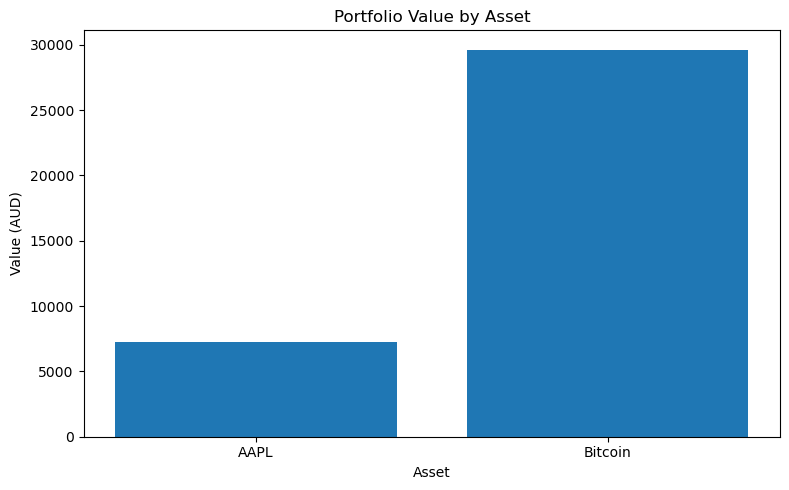

Chart saved: charts/asset_values.png


In [122]:
plt.figure(figsize=(8, 5))

plt.bar(
    portfolio_df["asset"],
    portfolio_df["value_aud"]
)

plt.title("Portfolio Value by Asset")
plt.xlabel("Asset")
plt.ylabel("Value (AUD)")

plt.tight_layout()

asset_chart = CHART_DIR / "asset_values.png"

plt.savefig(asset_chart)

plt.show()

print("Chart saved:", asset_chart)


### Create Allocation Chart

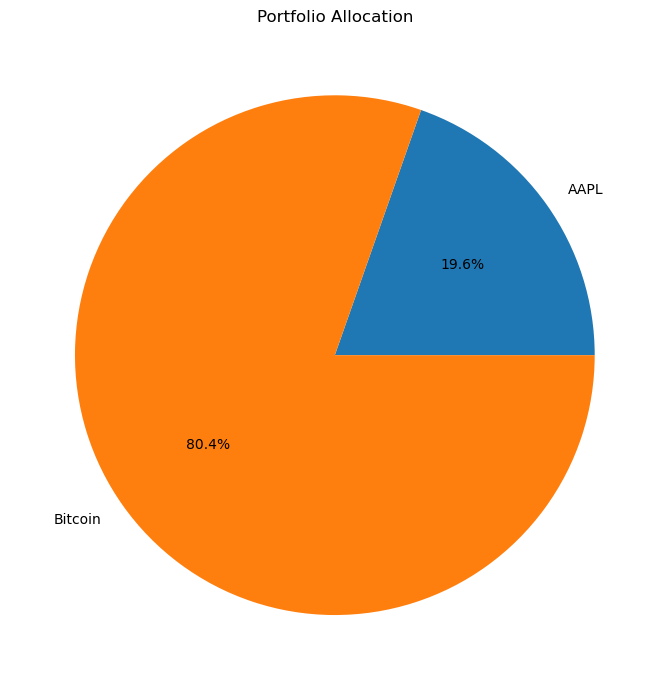

Chart saved: charts/asset_allocation.png


In [123]:
plt.figure(figsize=(7, 7))

plt.pie(
    portfolio_df["value_aud"],
    labels=portfolio_df["asset"],
    autopct="%1.1f%%"
)

plt.title("Portfolio Allocation")

plt.tight_layout()

allocation_chart = (
    CHART_DIR / "asset_allocation.png"
)

plt.savefig(allocation_chart)

plt.show()

print("Chart saved:", allocation_chart)




### Finally Close Database Connection

In [124]:
connection.close()

print("SQLite connection closed.")

SQLite connection closed.
